In [5]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# 1. Load Data 
df = pd.read_csv('data/loan_data.csv')

# 2. Preprocessing
df = pd.get_dummies(df, columns=['purpose'], drop_first=True)

# 3. Define Features and Target
X = df.drop('not.fully.paid', axis=1)
y = df['not.fully.paid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train XGBoost Model
model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05)
model.fit(X_train, y_train)

# 5. Predict PD
df['PD'] = model.predict_proba(X)[:, 1]
print(f"Model AUC-ROC: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])}")

Model AUC-ROC: 0.6758372256311628


In [6]:
# Assuming 45% loss if they default
df['Expected_Loss_INR'] = df['PD'] * 0.45 * df['installment']

In [8]:
from imblearn.over_sampling import SMOTE

# Banks deal with 'Imbalanced Data'
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# Retrain on balanced data for better sensitivity to risk
model.fit(X_res, y_res)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [9]:
# Create a 'Recession Scenario'
df_stress = df.copy()
df_stress['log.annual.inc'] = df_stress['log.annual.inc'] * 0.80 # 20% Income drop
df_stress['int.rate'] = df_stress['int.rate'] + 0.05 # 5% Interest hike

# Re-calculate PD under stress
df['Stress_PD'] = model.predict_proba(df_stress.drop(['not.fully.paid', 'PD', 'Expected_Loss_INR'], axis=1, errors='ignore'))[:, 1]
df['Risk_Delta'] = df['Stress_PD'] - df['PD']

In [12]:
def assign_product(row):
    if row['PD'] < 0.10 and row['fico'] > 750:
        return 'Private Wealth'
    elif row['PD'] < 0.20 and row['fico'] > 680:
        return 'Signature Credit Card'
    elif row['PD'] > 0.40:
        return 'Debt Consolidation Loan'
    else:
        return 'Standard Savings'

df['Target_Product'] = df.apply(assign_product, axis=1)

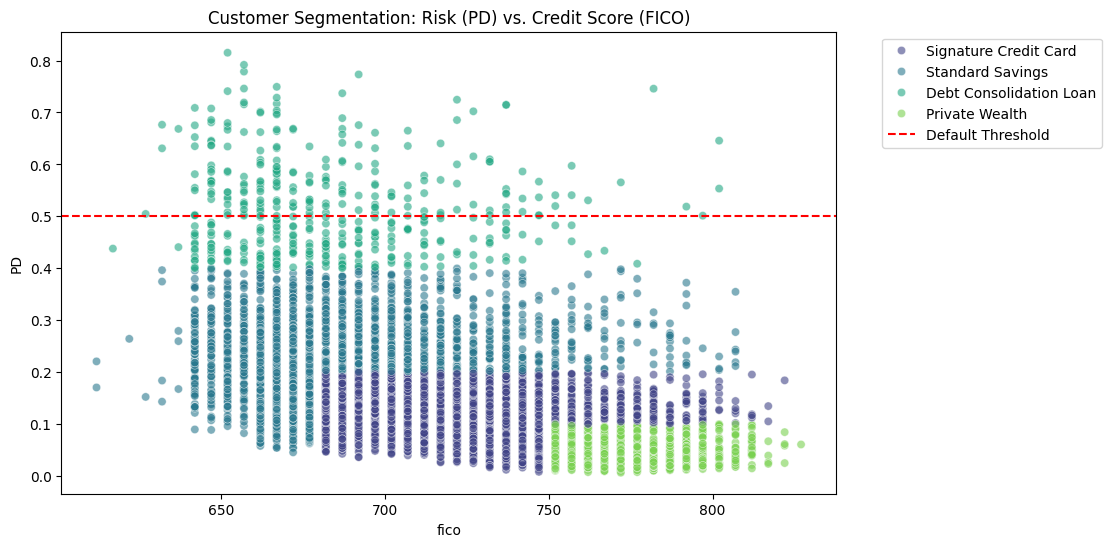

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='fico', y='PD', hue='Target_Product', palette='viridis', alpha=0.6)
plt.title('Customer Segmentation: Risk (PD) vs. Credit Score (FICO)')
plt.axhline(0.5, color='red', linestyle='--', label='Default Threshold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()